In [13]:
# Maybe also look at changes to the proportion of events falling onto soils with different properties?

In [14]:
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats

from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

## Get a list of catchments which have flood outputs and rainfall detail outputs

In [15]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)
print(len(catchments_with_flood_output))

112


### Join together results for all these catchments, remove mismatched rows, add a catchment number flag

In [16]:
rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    

Catchment 12 has 621, of which 0 are mismatched
Catchment 78 has 382, of which 0 are mismatched
Catchment 27_b has 1237, of which 0 are mismatched
Catchment 38 has 350, of which 0 are mismatched
Catchment 64 has 1381, of which 0 are mismatched
Catchment 88 has 899, of which 0 are mismatched
Catchment 53 has 638, of which 0 are mismatched
Catchment 24 has 618, of which 0 are mismatched
Catchment 51 has 565, of which 0 are mismatched
Catchment 28_a has 983, of which 0 are mismatched
Catchment 54_b has 1065, of which 0 are mismatched
Catchment 40 has 1666, of which 0 are mismatched
Catchment 13 has 481, of which 0 are mismatched
Catchment 86 has 1039, of which 9 are mismatched
Catchment 77 has 421, of which 0 are mismatched
Catchment 68 has 351, of which 0 are mismatched
Catchment 45 has 1503, of which 0 are mismatched
Catchment 58 has 1444, of which 0 are mismatched
Catchment 81 has 644, of which 0 are mismatched
Catchment 80 has 666, of which 0 are mismatched
Catchment 52 has 1307, of w

In [17]:
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<150].copy()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Categorising Hydraulic Conductivity (HC)

Soils are categorised into three classes based on hydraulic conductivity:
- **Low HC**: very impermeable soils (e.g., clay)
- **Medium HC**: moderately permeable soils (e.g., loam)
- **High HC**: very permeable soils (e.g., sand/gravel)


---

<details>
<summary> More info (click to expand)</summary>


## Expected Impact of HC on Sensitivity to Antecedent Conditions

### Low HC (Clay-dominated soils)
Clay soils have very small pore sizes and poor drainage, meaning water movement through the soil profile is slow. This produces several important characteristics:
- **Wet antecedent conditions persist** — once saturated, clay takes a long time to drain between events, giving the soil a long "memory" of previous rainfall
- **Infiltration capacity is low even when dry** — when wet, essentially all rainfall becomes runoff almost immediately
- **The contrast between wet and dry states is large and consequential** — a dry clay soil retains some residual capacity, a wet one has almost none, meaning antecedent state is a primary control on flood response
- In a warming climate, if summers become drier, clay soils might see *reduced* flood risk from individual events (greater buffering capacity), but autumn/winter events following wet periods could become more severe

### Medium HC (Loam-type soils)
- Moderate drainage means antecedent conditions matter, but less persistently than in clay soils
- These soils can partially recover between events, so the soil moisture signal may be more sensitive to the **specific lag time** used
- Likely the most variable class and hardest to generalise about

### High HC (Sandy/gravelly soils)
Sandy soils have large pore sizes and drain rapidly, leading to fundamentally different behaviour:
- **Antecedent conditions dissipate quickly** — even after a wet period, sandy soils can drain sufficiently between events that their state at the time of the next event is less extreme
- **Infiltration capacity remains high even when wet** — a large fraction of rainfall is absorbed regardless of antecedent state, reducing the contrast between wet and dry conditions
- **Flood response is more directly controlled by rainfall intensity** — flooding occurs when rainfall rate exceeds infiltration capacity (Hortonian overland flow), driven by storm characteristics rather than antecedent moisture

---

## Broader Implication

This framework suggests that the **dominant driver of flood generation differs spatially** across the UK:

| Soil Type | Dominant Flood Driver | Key Future Climate Sensitivity |
|---|---|---|
| Low HC (clay) | Antecedent soil moisture state | Changes in soil moisture seasonality |
| High HC (sand) | Rainfall intensity | Changes in extreme rainfall statistics |

These two pathways have different implications for how climate change translates into flood risk, and for which adaptation strategies are most relevant — making the spatial map of HC sensitivity a potentially important result. 

</details>


</div>

In [18]:
rainfall_events_all_df_lowHC = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]
rainfall_events_all_df_medHC = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.7)]
rainfall_events_all_df_highHC = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] > 0.7]

rainfall_events_all_df['HC_status'] = pd.cut( rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.3, 0.7, float('inf')],  labels=['low (clay)', 'medium', 'high (sand)'],right=False)

In [19]:
hc_groups = {'low (clay)': rainfall_events_all_df_lowHC,
             'medium (?)': rainfall_events_all_df_medHC,
             'high (sandy)': rainfall_events_all_df_highHC}

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## How do antecedent conditions vary for rainfall events occurring on different soil types?
    
- **Low HC (clay):** Antecedent soil moisture conditions mostly between around 60-80 (soils generally wet when events occur)
- **Medium HC:** Similar but slightly broader range and shifted slightly lower
- **High HC (sand):** Dramatically wider and shifted right towards very high SM values (80-110) — but also with a long left tail down to near zero
    
</div>

In [20]:
colors = ["#2c7bb6", "#fdae61", "#d7191c"]

In [21]:
rainfall_events_all_df_highHC

,max_precip,t_global,t_local,x_idx,y_idx,x_idx_global,y_idx_global,x_coord,y_coord,ens,...,cluster_n_cells_t80,threshold_flood_10_area_t80,cluster_flood_10_area_t80,threshold_flood_10_vol_t80,cluster_flood_10_vol_t80,threshold_flood_30_area_t80,cluster_flood_30_area_t80,threshold_flood_30_vol_t80,cluster_flood_30_vol_t80,catchment_num
0,48.491825,6543,2,14,5,112,167,362500.0,802500.0,01,...,1,0.5094,0.5094,134650.796875,134650.796875,0.1107,0.1107,61947.000000,61947.000000,12
1,30.496033,6729,2,14,2,112,164,362500.0,787500.0,01,...,1,0.0063,0.0063,1978.199951,1978.199951,0.0009,0.0009,562.500000,562.500000,12
2,30.412142,5943,20,8,1,106,163,332500.0,782500.0,01,...,1,0.3735,0.0477,108558.898438,9540.900391,0.0414,0.0054,41894.097656,2304.899902,12
3,31.363464,6229,4,10,4,108,166,342500.0,797500.0,01,...,1,0.0000,0.0000,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,12
4,30.051565,5892,2,13,5,111,167,357500.0,802500.0,01,...,1,0.0189,0.0189,3939.300049,3939.300049,0.0018,0.0018,752.399963,752.399963,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101840,45.878136,6014,3,6,4,96,123,282500.0,582500.0,15,...,1,0.7101,0.7101,183870.906250,183870.906250,0.1098,0.1098,63078.300781,63078.300781,79
101841,30.448071,7434,13,4,7,94,126,272500.0,597500.0,15,...,1,0.4293,0.3078,190262.703125,106109.101562,0.0747,0.0459,79128.898438,36542.699219,79
101842,30.434135,7698,4,1,10,91,129,257500.0,612500.0,15,...,1,0.0081,0.0081,1835.099976,1835.099976,0.0000,0.0000,0.000000,0.000000,79
101844,30.048286,5892,3,3,9,93,128,267500.0,607500.0,15,...,1,0.0000,0.0000,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,79


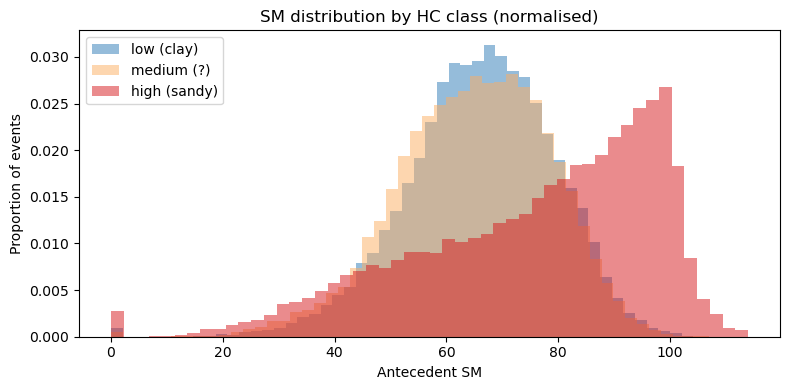

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
i=0
for hc_label, hc_df in hc_groups.items():
    hc_df['mean_sm_2_before_event'].plot.hist(ax=ax, alpha=0.5, bins=50, label=hc_label,density=True, color = colors[i])
    i=i+1
ax.set_xlabel('Antecedent SM')
ax.set_ylabel('Proportion of events')
ax.legend()
ax.set_title('SM distribution by HC class (normalised)')
plt.tight_layout()

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## How do antecedent conditions change in future for different soil types?
    
- Low HC (clay): Antecedent soil moisture conditions getting drier
- Medium HC: Antecedent soil moisture conditions getting drier
- High HC (sand): Antecedent soil moisture conditions getting wetter
    
Implications of this:
- Clay soils are almost always wet when AMAX events occur: less variability to differentiate over
    - Is this because Clay soils are basically always wet, or only when we sample the AMAX events?
</div>

In [23]:
cmap = plt.get_cmap('Reds')
values = np.linspace(0.2, 0.9, 3)
colors = [cmap(v) for v in values]

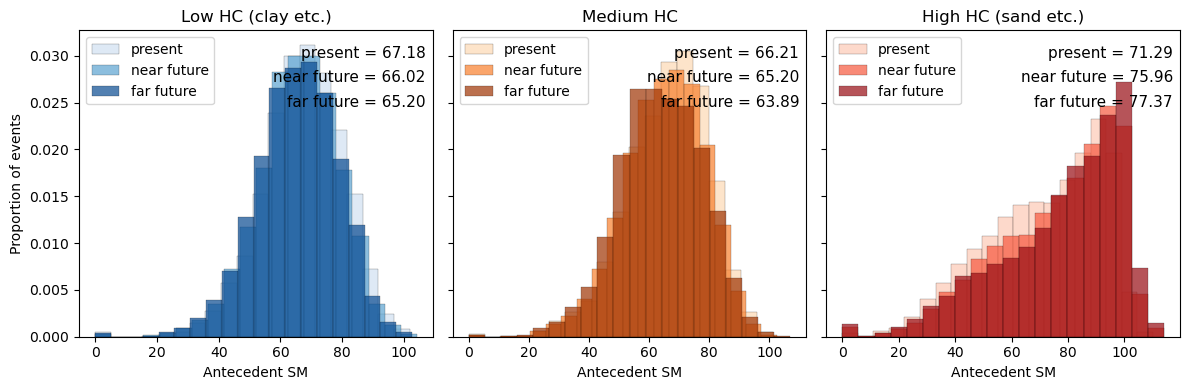

In [24]:
fig, axs = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)
titles = ['Low HC (clay etc.)', 'Medium HC', 'High HC (sand etc.)']
color_ramps = [ 'Blues', 'Oranges', 'Reds']
for ax_num, rainfall_events in enumerate([
    rainfall_events_all_df_lowHC,
    rainfall_events_all_df_medHC,
    rainfall_events_all_df_highHC]):
    
    cmap = plt.get_cmap(color_ramps[ax_num])
    values = np.linspace(0.2, 0.9, 3)
    colors = [cmap(v) for v in values]
    
    year_groups = { 'present': rainfall_events[rainfall_events['start_year'] < 2020],
        'near future': rainfall_events[(rainfall_events['start_year'] >= 2020) & (rainfall_events['start_year'] <= 2050)],
        'far future': rainfall_events[rainfall_events['start_year'] > 2050], }

    # Plot + annotate
    for i, (hc_label, hc_df) in enumerate(year_groups.items()):
        hc_df['mean_sm_2_before_event'].plot.hist(
            ax=axs[ax_num],
            alpha=0.7,
            bins=20,
            label=hc_label,
            density=True,
            color=colors[i],
            edgecolor = 'black', linewidth=0.2)
        
        mean_val = hc_df['mean_sm_2_before_event'].mean()
        
        axs[ax_num].text(0.98,  0.95 - i*0.08, f"{hc_label} = {mean_val:.2f}",
            transform=axs[ax_num].transAxes, ha='right', va='top', fontsize=11)

    axs[ax_num].set_xlabel('Antecedent SM')
    axs[ax_num].set_ylabel('Proportion of events')
    axs[ax_num].legend()
    
    axs[ax_num].set_title(titles[ax_num])

plt.tight_layout()

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Do events tend to happen at different times of year on different soil types?
    
- Low HC (clay): Mostly tightly concentrated around summer
- Medium HC: Mostly tightly concentrated around summer
- High HC (sand): Fatter tail into winter (days 280-360) and also more events in early spring (days 0-100)
    
Sandier soils experience more winter events proportionally.      
</div>

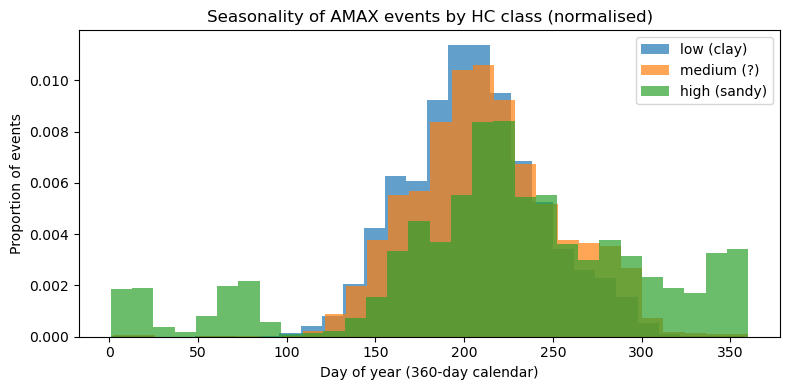

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
for hc_label, hc_df in hc_groups.items():
    hc_df['day_360'].plot.hist( ax=ax, alpha=0.7, bins=30, label=hc_label, density=True)
ax.set_xlabel('Day of year (360-day calendar)')
ax.set_ylabel('Proportion of events')
ax.legend()
ax.set_title('Seasonality of AMAX events by HC class (normalised)')
plt.tight_layout()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Exploratory plots: Does the rainfall-flood relationship change across HC classes?
- Relationship beteen rainfall and flooding is strongest in the high HC cells (it is slightly higher in the low HC cells than the medium ones)

</div>

In [26]:
def get_fit_stats(df, x_col, y_col):
    """Returns slope, r-squared, and p-value for a linear fit."""
    clean = df[[x_col, y_col]].dropna()
    slope, intercept, r, p, se = stats.linregress(clean[x_col], clean[y_col])
    return {'slope': slope, 'r2': r**2, 'pvalue': p, 'n': len(clean)}

metrics = [('max_precip', '10cm_area'),
#            ('max_precip', '30cm_area'),
#            ('max_precip', '10cm_volume'),
#            ('max_precip', '30cm_volume')
          ]

hc_groups = {'low (clay)': rainfall_events_all_df_lowHC,
             'medium (?)': rainfall_events_all_df_medHC,
             'high (sandy)': rainfall_events_all_df_highHC}

rows = []
for hc_label, hc_df in hc_groups.items():
    for (x, y) in metrics:
        stats_dict = get_fit_stats(hc_df, x, y)
        rows.append({'HC_class': hc_label, 'x': x, 'y': y, **stats_dict})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

    HC_class          x         y    slope       r2  pvalue     n
  low (clay) max_precip 10cm_area 0.029548 0.200679     0.0 28881
  medium (?) max_precip 10cm_area 0.018160 0.190126     0.0 38508
high (sandy) max_precip 10cm_area 0.012014 0.434336     0.0 34744


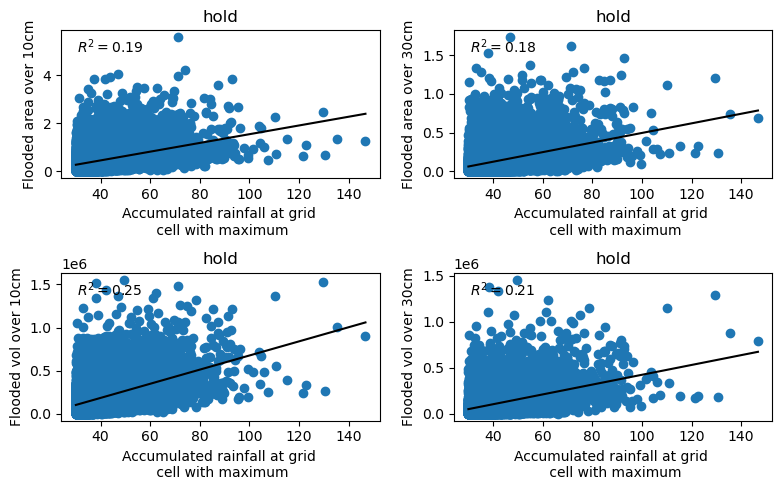

In [27]:
rainfall_events = rainfall_events_all_df_medHC

title = 'hold'
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,5))
axs=axs.flatten()
plotting_dict1 = {('max_precip', '10cm_area'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 10cm')}
plotting_dict2 = {('max_precip', '30cm_area'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 30cm')}
plotting_dict3 = {('max_precip', '10cm_volume'): ('Accumulated rainfall at grid \n cell with maximum','Flooded vol over 10cm')}
plotting_dict4 = {('max_precip', '30cm_volume'): ('Accumulated rainfall at grid \n cell with maximum','Flooded vol over 30cm')}

for ax_num, plotting_dict in enumerate([plotting_dict1, plotting_dict2, plotting_dict3, plotting_dict4]):
    for (variable1, variable2), (var_name1, var_name2) in plotting_dict.items():
        plot_with_best_fit_line(rainfall_events, axs[ax_num], variable1, variable2, var_name1, var_name2, title)
fig.tight_layout()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Show the mean flood response as a joint function of rainfall AND soil moisture, binned)
      

</div>

/tmp/ipykernel_121129/3131264214.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['precip_bin', 'sm_bin'])[flood_metric].mean().unstack()
/tmp/ipykernel_121129/3131264214.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['precip_bin', 'sm_bin'])[flood_metric].mean().unstack()
/tmp/ipykernel_121129/3131264214.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.

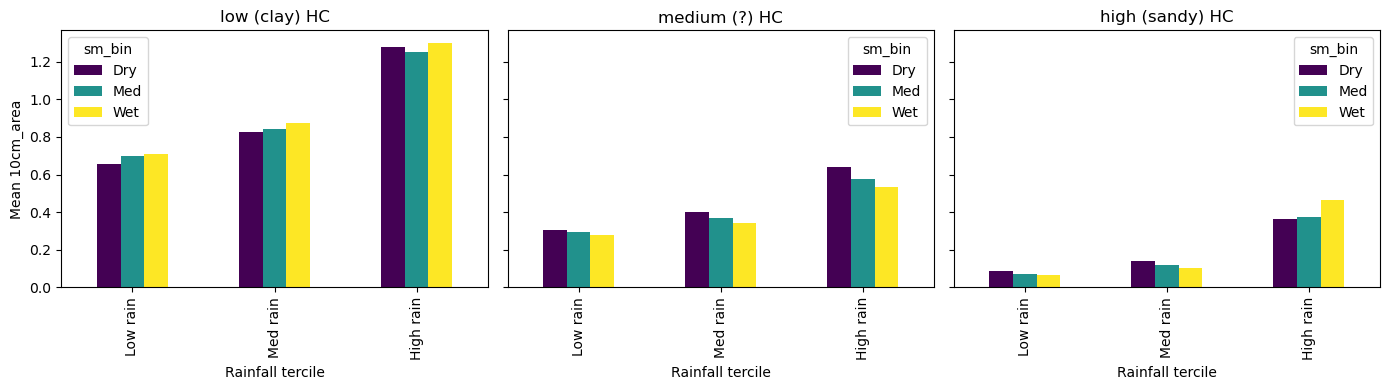

In [28]:
def plot_binned_sm_effect(df, flood_metric, hc_label, ax):
    df = df[['max_precip', 'mean_sm_2_before_event', flood_metric]].dropna()
    
    # Bin both rainfall and SM into terciles
    df['precip_bin'] = pd.qcut(df['max_precip'], 3, labels=['Low rain', 'Med rain', 'High rain'])
    df['sm_bin'] = pd.qcut(df['mean_sm_2_before_event'], 3, labels=['Dry', 'Med', 'Wet'])
    
    grouped = df.groupby(['precip_bin', 'sm_bin'])[flood_metric].mean().unstack()
    grouped.plot(kind='bar', ax=ax, colormap='viridis')
    ax.set_title(f'{hc_label} HC')
    ax.set_xlabel('Rainfall tercile')
    ax.set_ylabel(f'Mean {flood_metric}')

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (hc_label, hc_df) in zip(axs, hc_groups.items()):
    plot_binned_sm_effect(hc_df, '10cm_area', hc_label, ax)
fig.tight_layout()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Explore the partial R2 - for just high/med/low HC events

</div>

/tmp/ipykernel_121129/2979089126.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for catch_id, group in rainfall_events_all_df.groupby('HC_status'):


,HC_status,sm_sensitivity,hc_median,n_events,x_coord,y_coord
0,low (clay),0.000192,0.158583,28881,442500.0,237500.0
1,medium,0.006583,0.346694,38508,297500.0,267500.0
2,high (sand),0.001299,1.089658,34744,217500.0,762500.0


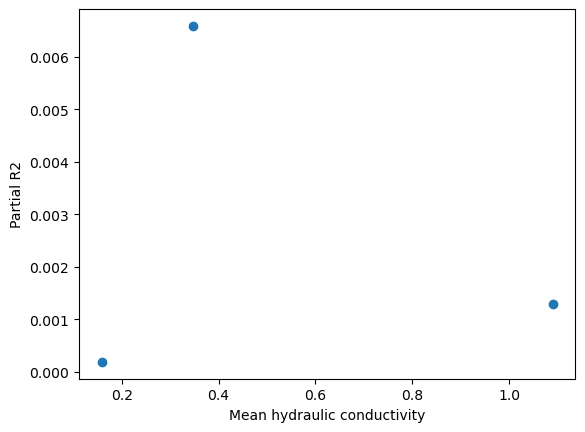

In [29]:
# Apply across catchments
results = []
for catch_id, group in rainfall_events_all_df.groupby('HC_status'):
    score = partial_r2_for_catchment(group, flood_metric='10cm_area')
    hc_median = group['hc_at_peak'].median()
    results.append({
        'HC_status': catch_id,
        'sm_sensitivity': score,
        'hc_median': hc_median,
        'n_events': len(group),
        'x_coord': group['x_coord'].median(),
        'y_coord': group['y_coord'].median(),
    })

results_df = pd.DataFrame(results)
plt.scatter(results_df['hc_median'], results_df['sm_sensitivity'])
plt.xlabel('Mean hydraulic conductivity')
plt.ylabel('Partial R2')
results_df

In [30]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import statsmodels.formula.api as smf
import statsmodels.api as sm

df = rainfall_events_all_df


# --- Setup ---
sm_cols = ['mean_sm_2_before_event', 'mean_sm_3_before_event',
           'mean_sm_4_before_event', 'mean_sm_5_before_event']

storm_cols = ['max_precip', 'gini', 'd50', 'peak_position_ratio',
              'dry_ratio', 'time_based_std', 'total_acc']

flood_metric = '10cm_area'

# --- Prepare data ---
cols_needed = sm_cols + storm_cols + ['hc_at_peak', 'catchment_num', flood_metric]
df_model = df[cols_needed].dropna().copy()

# Standardise continuous variables (important for interpretable interaction terms)
scaler = StandardScaler()
cols_to_scale = sm_cols + storm_cols + ['hc_at_peak']
df_model[cols_to_scale] = scaler.fit_transform(df_model[cols_to_scale])

# Create catchment dummies (fixed effects)
catchment_dummies = pd.get_dummies(df_model['catchment_num'], prefix='catch', drop_first=True)
df_model = pd.concat([df_model, catchment_dummies], axis=1)

# --- Build feature matrices ---
dummy_cols = catchment_dummies.columns.tolist()

# Interaction terms: hc_at_peak × each SM lag
interaction_cols = []
for sm_col in sm_cols:
    col_name = f'hc_x_{sm_col}'
    df_model[col_name] = df_model['hc_at_peak'] * df_model[sm_col]
    interaction_cols.append(col_name)

# Base model: storm features + catchment FE (no SM)
base_cols = storm_cols + ['hc_at_peak'] + dummy_cols

# Full model: adds SM + interactions
full_cols = base_cols + sm_cols + interaction_cols

X_base = df_model[base_cols].values
X_full = df_model[full_cols].values
y = df_model[flood_metric].values

# --- Fit models ---
model_base = LinearRegression().fit(X_base, y)
model_full = LinearRegression().fit(X_full, y)

r2_base = r2_score(y, model_base.predict(X_base))
r2_full = r2_score(y, model_full.predict(X_full))

print(f"Base R²: {r2_base:.3f}")
print(f"Full R²: {r2_full:.3f}")
print(f"Partial R² of SM + interactions: {r2_full - r2_base:.3f}")

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# Build formula string dynamically
formula_terms = (
    storm_cols +
    ['hc_at_peak'] +
    sm_cols +
    interaction_cols +
    [f'C(catchment_num)']  # statsmodels handles dummies automatically
)

# formula = f"{flood_metric} ~ " + " + ".join(
#     storm_cols + ['hc_at_peak'] + sm_cols + interaction_cols + ['C(catchment_num)'])
formula = f"Q('{flood_metric}') ~ " + " + ".join(
    storm_cols + ['hc_at_peak'] + sm_cols + interaction_cols + ['C(catchment_num)']
)

sm_model = smf.ols(formula, data=df_model).fit()
print(sm_model.summary())

# Pull out just the interaction terms for inspection
interaction_results = sm_model.params[interaction_cols].to_frame('coefficient')
interaction_results['pvalue'] = sm_model.pvalues[interaction_cols]
interaction_results['ci_low'] = sm_model.conf_int()[0][interaction_cols]
interaction_results['ci_high'] = sm_model.conf_int()[1][interaction_cols]
print(interaction_results)

In [ ]:
# Create a synthetic grid: vary SM and HC, hold everything else at mean (i.e. 0 after scaling)
hc_values = np.linspace(df_model['hc_at_peak'].min(),
                        df_model['hc_at_peak'].max(), 100)

sm_col_to_plot = 'mean_sm_2_before_event'  # closest lead time, most physically meaningful
interaction_col = f'hc_x_{sm_col_to_plot}'

fig, ax = plt.subplots(figsize=(8, 5))

for sm_level, label, color in [(-1, 'Dry antecedent (−1 SD)', 'orange'),
                                 (0,  'Average antecedent', 'grey'),
                                 (1,  'Wet antecedent (+1 SD)', 'steelblue')]:
    
    # Predicted flood response as HC varies, at fixed SM level
    # All other terms = 0 (mean after standardisation), catchment FE drops out
    preds = (sm_model.params['hc_at_peak'] * hc_values +
             sm_model.params[sm_col_to_plot] * sm_level +
             sm_model.params[interaction_col] * hc_values * sm_level)
    
    ax.plot(hc_values, preds, label=label, color=color, lw=2)

ax.set_xlabel('Hydraulic Conductivity (standardised)')
ax.set_ylabel(f'Predicted {flood_metric} (marginal contribution)')
ax.set_title('How HC modulates sensitivity to antecedent soil moisture')
ax.legend()
ax.axhline(0, color='black', lw=0.5, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# from pyproj import Transformer
# # Define transformer (WGS84 → BNG)
# transformer = Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)
# # Newcastle coordinates (lon, lat!)
# lon, lat = -1.601382, 54.970304
# newcastle_x, newcastle_y = transformer.transform(lon, lat)
# # Euclidean distance in metres (BNG is in metres)
# dist = np.sqrt((rainfall_events['x_coord'] - newcastle_x)**2 +(rainfall_events['y_coord'] - newcastle_y)**2)
# # Create boolean column (within 10 km = 10,000 m)
# rainfall_events['within_10km_city_centre'] = dist <= 10000
# rainfall_events['distance_to_city_centre'] = dist
# near_newcastle = rainfall_events[rainfall_events["within_10km_city_centre"]==True]
# plt.scatter(rainfall_events['hc_at_peak'], rainfall_events['distance_to_city_centre'])

In [ ]:
title = 'hold'
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs=axs.flatten()
plotting_dict1 = {('start_year', 'max_precip'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 10cm')}
plotting_dict2 = {('start_year', 'total_acc'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 30cm')}

for ax_num, plotting_dict in enumerate([plotting_dict1, plotting_dict2]):
    for (variable1, variable2), (var_name1, var_name2) in plotting_dict.items():
        plot_with_best_fit_line(rainfall_events, axs[ax_num], variable1, variable2, var_name1, var_name2, title)
fig.tight_layout()

In [ ]:
rainfall_events_all_df["random_id"] = np.random.randint(low=1, high=9, size=len(rainfall_events_all_df))

In [ ]:
predictor_variable = '10cm_area'
explainer_variables = rainfall_events_all_df.columns
stuff = {'t_global', 't_local', 'mismatch', 'hydro_day_360', 'rainfall_peak_day', 'values', 'times',
        "max_precip_from_csv", "t_local_rebased", "start_idx", "stop_idx", "time_mismatch", "HC_status"}
flood_output_vars = { '10cm_area', '10cm_volume',  '30cm_area', '30cm_volume', 'neighbourhood_flood_10_area',
                     'neighbourhood_flood_10_vol', 'neighbourhood_flood_30_area', 'neighbourhood_flood_30_vol',
                    'threshold_flood_10_area_t50', 'cluster_flood_10_area_t50', 'threshold_flood_10_vol_t50',
 'cluster_flood_10_vol_t50', 'threshold_flood_30_area_t50', 'cluster_flood_30_area_t50', 'threshold_flood_30_vol_t50',
 'cluster_flood_30_vol_t50', 'threshold_flood_10_area_t60', 'cluster_flood_10_area_t60', 'threshold_flood_10_vol_t60',
 'cluster_flood_10_vol_t60', 'threshold_flood_30_area_t60',  'cluster_flood_30_area_t60',  'threshold_flood_30_vol_t60',
 'cluster_flood_30_vol_t60', 'threshold_flood_10_area_t80', 'cluster_flood_10_area_t80', 'threshold_flood_10_vol_t80', 
'cluster_flood_10_vol_t80', 'threshold_flood_30_area_t80', 'cluster_flood_30_area_t80', 'threshold_flood_30_vol_t80',
                     'cluster_flood_30_vol_t80' }
spatial_vars = {'y_idx', 'y_idx_global', 'y_coord', 'x_coord', 'x_idx', 'x_idx_global'}
explainer_variables = [item for item in explainer_variables if item not in stuff and item not in flood_output_vars
                       and item not in spatial_vars]

In [ ]:
# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(rainfall_events_all_df[explainer_variables], 
                                                    rainfall_events_all_df[predictor_variable], 
                                                    test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model performance
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

In [ ]:
plt.scatter(rainfall_events_all_df["10cm_area"], rainfall_events_all_df['max_precip'])

In [ ]:
import seaborn as sns

# Assuming 'rf' is your trained RandomForestRegressor
feature_importances = pd.Series(rf.feature_importances_, index=explainer_variables)

# Sort descending
feature_importances = feature_importances.sort_values(ascending=False)

# Print
print(feature_importances)

# Optional: plot
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
from scipy.stats import linregress
df = near_newcastle.copy()
explainer_varible = 'mean_sm_2_before_event'
x = df['total_acc']
y = df['10cm_fld_area_at_peak']

# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Predicted values
y_pred = intercept + slope * x

# Residuals
df['residuals'] = y - y_pred

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df[explainer_varible], df['residuals'])

plt.axhline(0, linestyle='--')  # reference line
plt.xlabel('Mean soil moisture')
plt.ylabel('Residual flood area')
plt.title('Residuals vs Soil Moisture')

plt.show()